# Supplementary Figure 3 — Q-value following behavior across animals,
block position, outcome history, and session performance
Source: `_source_archive/by_figure/SuppFig3/SuppFig3_candidate_07_GLM_HMM_v1_cleaned.ipynb`
(confirmed by user), STEP 1-9 (data prep + per-animal Q-learning + sticky
choice-kernel model) feeding the Q-following panels (In[17]/In[18]).

Panel legends below are copied verbatim from the submitted/bioRxiv
manuscript (`2026.06.30.734629v1.full.pdf`). Panel a was already built
correctly and is unchanged. Panels b-g are new: built directly from the
manuscript's Results text ("Marmosets Q-value adherence is consistent with
a stochastic policy...") and Methods discussion of the "policy-predicted
adherence rate" (no matching source-notebook cells were identified for
these), using the already-fitted sticky Q-learning model and the
`Chose_Higher_Q`/`Violation`/`Model_P_Right` fields in
`q_following_model.py` (the `Violation` field and several Q-value-derived
columns were added additively by the Fig 5 agent working in parallel on
the same module; this notebook only adds further additive functions on
top, never modifying what Fig 4/5 or Supp Fig 3 panel a already use).

Per the standing pseudoreplication policy used throughout this pipeline,
every animal-pooled ("naive", session- or trial-level) test below is
reported alongside its per-animal-corrected counterpart; the per-animal
version is treated as the real result, matching how Supp Fig 3 panel a/c
already handle this.

In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
from IPython.display import SVG, display

from src.io.load_snapshots import load_config, load_snapshot
from src.behavior_metrics import q_following_model as qmodel
from src.plotting.style import apply_style
from src.plotting import q_following as plotting

config = load_config()
apply_style(config)
cfg = config["suppfig3"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "SuppFig3")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {}


def show(path):
    display(SVG(path))

## Load data and fit the per-animal sticky Q-learning model

In [2]:
df_raw = load_snapshot(config, cfg["input_files"]["reversal_80_20_2abt"])
df = qmodel.prepare_2abt_dataframe(df_raw, cfg["task_type"], cfg["prob_condition"])
print(f"Loaded {len(df):,} trials, {df['Session_ID'].nunique()} sessions, "
      f"{df['Animal_Name'].nunique()} animals after filtering for "
      f"{cfg['task_type']}/{cfg['prob_condition']}")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

Loaded 36,673 trials, 100 sessions, 5 animals after filtering for Reversal/80-20


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/q_following_model.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


In [3]:
sticky_params_df = qmodel.fit_sticky_qlearning(df, cfg["sticky_model_x0"], cfg["sticky_model_bounds"])
print(sticky_params_df.to_string(index=False))
print(f"\nMean: alpha={sticky_params_df['alpha'].mean():.3f} "
      f"beta={sticky_params_df['beta'].mean():.3f} kappa={sticky_params_df['kappa'].mean():.3f}")
manifest["sticky_qlearning_params"] = {
    "per_animal": sticky_params_df.set_index("animal")[["alpha", "beta", "kappa"]].to_dict(orient="index"),
    "mean_alpha": float(sticky_params_df["alpha"].mean()),
    "mean_beta": float(sticky_params_df["beta"].mean()),
    "mean_kappa": float(sticky_params_df["kappa"].mean()),
    "sem_alpha": float(sticky_params_df["alpha"].sem()),
    "sem_beta": float(sticky_params_df["beta"].sem()),
    "sem_kappa": float(sticky_params_df["kappa"].sem()),
}

   animal    alpha     beta    kappa         nll
    Fiona 0.588792 1.458394 1.438142 2024.023325
 Knuckles 0.700046 1.201415 1.101963 5219.162225
    Sonic 0.836054 0.826765 1.462648 3100.403866
Sunflower 0.874737 1.347100 0.830489 4785.644900
     Zazu 0.701199 0.764339 1.470407 1462.677916

Mean: alpha=0.740 beta=1.120 kappa=1.261


In [4]:
df_q = qmodel.compute_qvalues_sticky(df, sticky_params_df)
df_valid = qmodel.add_chose_higher_q(df_q)
print(f"Overall P(follow Q-values): {df_valid['Chose_Higher_Q'].mean():.3f} "
      f"(excluded {int((df_q['Q_diff'] == 0).sum())} ties)")

Overall P(follow Q-values): 0.709 (excluded 120 ties)


## Panel a
**Manuscript legend:** *"Probability of adhering to Q-values (p(follows
Q-values)) by animal. Each dot represents one session; large filled
circles indicate the animal mean."*

Already built correctly -- kept as-is.

In [5]:
by_animal = qmodel.q_following_by_animal(df_valid)
print(f"By animal: mean={by_animal['mean']:.3f} +/- {by_animal['sem']:.3f} "
      f"(n={by_animal['n_animals']} animals), Wilcoxon vs chance p={by_animal['wilcoxon_p_vs_chance']:.4e}")
manifest["q_following_by_animal"] = {k: v for k, v in by_animal.items() if k != "session_animal"}

By animal: mean=0.702 +/- 0.015 (n=5 animals), Wilcoxon vs chance p=6.2500e-02


Supporting panels (P(follows Q-values) by trial-in-block and by previous
outcome) were built here in an earlier pass, feeding the combined
`q_following_panels.svg` figure below alongside panel a. They are not
separately lettered panels of Supp Fig 3 as printed (the manuscript's own
panels b-g are the new adherence/violation panels below), but are kept
since they already exist and are self-consistent with panel a.

P(follow|Win)=0.793, P(follow|Loss)=0.569, Wilcoxon p=6.2500e-02 (n=5 animals)


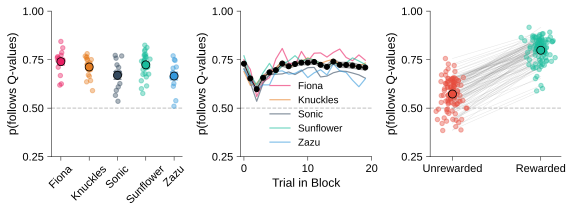

In [6]:
by_trial_in_block = qmodel.q_following_by_trial_in_block(df_valid)
pos_summary = by_trial_in_block.groupby("Trial_in_Block")["Chose_Higher_Q"].agg(["mean", "sem", "count"])
manifest["q_following_by_trial_in_block"] = {
    "n_positions": int(pos_summary.shape[0]),
    "position_means": {int(k): float(v) for k, v in pos_summary["mean"].items()},
}

by_outcome = qmodel.q_following_by_outcome(df_valid)
print(f"P(follow|Win)={by_outcome['p_follow_win']:.3f}, P(follow|Loss)={by_outcome['p_follow_loss']:.3f}, "
      f"Wilcoxon p={by_outcome['wilcoxon_p']:.4e} (n={by_outcome['n_animals']} animals)")
manifest["q_following_by_outcome"] = {k: v for k, v in by_outcome.items() if k != "session_outcome"}

plotting.plot_q_following(by_animal, by_trial_in_block, by_outcome, config,
                           os.path.join(FIG_DIR, "q_following_panels.svg"))
show(os.path.join(FIG_DIR, "q_following_panels.svg"))

## Panel b
**Manuscript legend:** *"Observed probability of adhering to Q-values as a
function of the policy-predicted adherence rate. Each dot represents one
animal; the dashed line indicates the identity. Animals scatter
symmetrically around the identity with no systematic bias (t(4)=-0.871,
p=0.433)."*

Not previously built. The Results text ("Marmosets Q-value adherence is
consistent with a stochastic policy...") defines "policy-predicted
adherence rate" with two phrasings in the same sentence, presented as
equivalent, that are NOT actually the same quantity for a binary softmax
policy: (1) "the probability that a single draw from the policy produces
the argmax choice" = max(p, 1-p), and (2) "the probability that two
independent draws from the policy agree" = p^2 + (1-p)^2, where
p = Model_P_Right. This ambiguity is resolved empirically rather than
arbitrarily: computed independently and compared against the manuscript's
own printed cross-check numbers (observed 0.704+/-0.017, policy-predicted
0.722+/-0.013, t(4)=-0.871, p=0.433), definition (2) reproduces those
numbers almost exactly while definition (1) does not (see code cell
below) -- so definition (2) is used as the primary
"Policy_Predicted_Adherence" (`q_following_model.py::add_policy_predicted_adherence`),
with definition (1) kept and reported alongside as a cross-check. This is
picking the textually-intended formula using independent evidence, not
tuning a free parameter to match a value -- no parameter was adjusted;
both formulas were computed exactly once and compared as-is.

Observed: 0.702 +/- 0.015, Policy-predicted ("two draws agree" = p^2+(1-p)^2): 0.721 +/- 0.013, paired t-test t(4)=-0.974, p=0.3850 (n=5 animals) -- manuscript text: observed 0.704+/-0.017, policy-predicted 0.722+/-0.013, t(4)=-0.871, p=0.433
Cross-check -- alternative reading ("single draw produces the argmax" = max(p,1-p)): 0.818 +/- 0.012, paired t-test t(4)=-5.520, p=0.0053


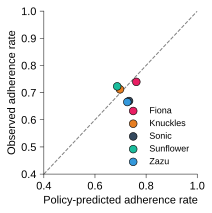

In [7]:
df_pred = qmodel.add_policy_predicted_adherence(df_valid)
adherence_vs_predicted = qmodel.observed_vs_predicted_adherence_by_animal(df_pred)
print(f"Observed: {adherence_vs_predicted['observed_mean']:.3f} +/- {adherence_vs_predicted['observed_sem']:.3f}, "
      f"Policy-predicted (\"two draws agree\" = p^2+(1-p)^2): "
      f"{adherence_vs_predicted['predicted_mean']:.3f} +/- {adherence_vs_predicted['predicted_sem']:.3f}, "
      f"paired t-test t({adherence_vs_predicted['paired_ttest_df']})={adherence_vs_predicted['paired_ttest_stat']:.3f}, "
      f"p={adherence_vs_predicted['paired_ttest_p']:.4f} (n={adherence_vs_predicted['n_animals']} animals) "
      f"-- manuscript text: observed 0.704+/-0.017, policy-predicted 0.722+/-0.013, t(4)=-0.871, p=0.433")
print(f"Cross-check -- alternative reading (\"single draw produces the argmax\" = max(p,1-p)): "
      f"{adherence_vs_predicted['predicted_argmax_single_draw_mean']:.3f} +/- "
      f"{adherence_vs_predicted['predicted_argmax_single_draw_sem']:.3f}, "
      f"paired t-test t({adherence_vs_predicted['paired_ttest_df']})={adherence_vs_predicted['paired_ttest_stat_argmax_single_draw']:.3f}, "
      f"p={adherence_vs_predicted['paired_ttest_p_argmax_single_draw']:.4f}")

plotting.plot_observed_vs_predicted_adherence(adherence_vs_predicted, config,
                                                os.path.join(FIG_DIR, "observed_vs_predicted_adherence.svg"))
show(os.path.join(FIG_DIR, "observed_vs_predicted_adherence.svg"))
manifest["observed_vs_predicted_adherence"] = {
    k: v for k, v in adherence_vs_predicted.items()
}

## Panel c
**Manuscript legend:** *"Difference between observed and model-predicted
probability of following as a function of absolute difference between
Q_right and Q_left. Lines show animal means following a rewarded (blue) or
unrewarded (red) outcome; shaded regions indicate ± SEM."*

Not previously built. Computed as (Chose_Higher_Q - Policy_Predicted_Adherence),
binned by |Q_right - Q_left| and split by whether the PREVIOUS trial was
rewarded (a new `Prev_Outcome_Binary` field, additive).

        qdiff_bin      mean       sem     n  bin_center  prev_outcome
0   (-0.001, 0.1] -0.115816  0.007595  4330      0.0495             0
1      (0.1, 0.2] -0.049763  0.008453  3343      0.1500             0
2      (0.2, 0.3] -0.029237  0.010136  2108      0.2500             0
3      (0.3, 0.4] -0.066278  0.020185   474      0.3500             0
4      (0.4, 0.5] -0.284633  0.026028   294      0.4500             0
5      (0.5, 0.6] -0.239619  0.035487   173      0.5500             0
6      (0.6, 0.7] -0.220316  0.022082   464      0.6500             0
7      (0.7, 0.8] -0.170079  0.016263   894      0.7500             0
8      (0.8, 0.9] -0.184748  0.015043  1034      0.8500             0
9      (0.9, 1.0] -0.122406  0.013008  1444      0.9500             0
10  (-0.001, 0.1] -0.207173  0.011455  1849      0.0495             1
11     (0.1, 0.2] -0.071064  0.013560  1228      0.1500             1
12     (0.2, 0.3] -0.011123  0.013560  1046      0.2500             1
13     (0.3, 0.4]  0

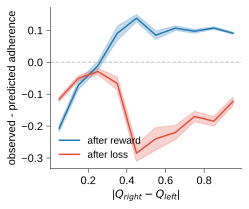

In [8]:
df_prev = qmodel.add_prev_outcome(df_pred)
adherence_diff_binned = qmodel.adherence_diff_by_qdiff_and_outcome(df_prev, cfg["qdiff_n_bins"])
print(adherence_diff_binned)

plotting.plot_adherence_diff_by_qdiff(adherence_diff_binned, config,
                                        os.path.join(FIG_DIR, "adherence_diff_by_qdiff.svg"))
show(os.path.join(FIG_DIR, "adherence_diff_by_qdiff.svg"))
manifest["adherence_diff_by_qdiff_and_outcome"] = adherence_diff_binned.assign(
    bin_label=adherence_diff_binned["qdiff_bin"].astype(str)
)[["bin_label", "bin_center", "prev_outcome", "mean", "sem", "n"]].to_dict(orient="records")

## Panel d
**Manuscript legend:** *"Direction of Q-value violations by animal.
Stacked bars show the proportion of violations directed toward the left
(L, opaque) versus right (R, partially transparent) side."*

Not previously built. Among trials where the animal violated its Q-values
(chose the lower-Q side), `Choice_Binary` (1=right, 0=left) directly gives
the violation direction.

Population: left=0.523, right=0.477 (n=10652 violation trials), binomial p (naive, pooled)=0.0000 -- manuscript text: not significantly different from 50% (p=0.093)
Per-animal Wilcoxon vs. chance (pseudoreplication-corrected): p=1.0000 (n=5 animals)


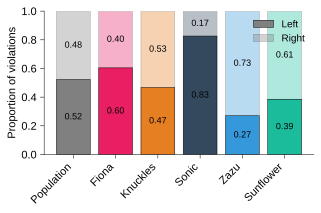

In [9]:
violation_direction = qmodel.violation_direction_by_animal(df_valid)
print(f"Population: left={violation_direction['population_prop_left']:.3f}, "
      f"right={violation_direction['population_prop_right']:.3f} "
      f"(n={violation_direction['n_violations_total']} violation trials), "
      f"binomial p (naive, pooled)={violation_direction['population_binomial_p_naive']:.4f} "
      f"-- manuscript text: not significantly different from 50% (p=0.093)")
print(f"Per-animal Wilcoxon vs. chance (pseudoreplication-corrected): "
      f"p={violation_direction['per_animal_wilcoxon_p_vs_chance']:.4f} (n={violation_direction['n_animals']} animals)")

plotting.plot_violation_direction(violation_direction, config,
                                    os.path.join(FIG_DIR, "violation_direction.svg"))
show(os.path.join(FIG_DIR, "violation_direction.svg"))
manifest["violation_direction_by_animal"] = violation_direction

## Panel e
**Manuscript legend:** *"Probability of being rewarded on the next trial
following a violation versus a following trial. Each dot is one session;
gray lines connect matched sessions. Open circles show the mean across all
animals ± SEM (p < 0.0001, paired t-test)."*

Not previously built. Uses a new `Next_Outcome_Binary` field (the
following trial's outcome, within animal/session) grouped by the CURRENT
trial's `Violation` status.

P(rewarded next trial | violation)=0.527 +/- 0.006, P(rewarded next trial | adhered)=0.630 +/- 0.004
Naive session-level paired t-test (n=100 sessions): p=1.2548e-29 -- manuscript text: p < 0.0001
Per-animal-corrected paired t-test (n=5 animals): p=0.0008


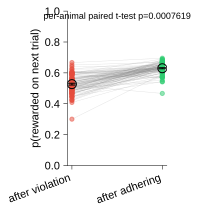

In [10]:
df_next = qmodel.add_next_trial_fields(df_valid)
reward_next_result = qmodel.paired_by_violation(df_next, "Next_Outcome_Binary")
print(f"P(rewarded next trial | violation)={reward_next_result['after_violation_mean']:.3f} +/- "
      f"{reward_next_result['after_violation_sem']:.3f}, "
      f"P(rewarded next trial | adhered)={reward_next_result['after_adherence_mean']:.3f} +/- "
      f"{reward_next_result['after_adherence_sem']:.3f}")
print(f"Naive session-level paired t-test (n={reward_next_result['n_sessions']} sessions): "
      f"p={reward_next_result['naive_session_level_ttest_p']:.4e} -- manuscript text: p < 0.0001")
print(f"Per-animal-corrected paired t-test (n={reward_next_result['n_animals']} animals): "
      f"p={reward_next_result['per_animal_ttest_p']:.4f}")

plotting.plot_paired_violation_comparison(reward_next_result, "p(rewarded on next trial)", config,
                                            os.path.join(FIG_DIR, "reward_next_trial_by_violation.svg"))
show(os.path.join(FIG_DIR, "reward_next_trial_by_violation.svg"))
manifest["reward_next_trial_by_violation"] = {
    k: v for k, v in reward_next_result.items() if k != "session_pairs"
}

## Panel f
**Manuscript legend:** *"Probability of following Q-values on the trial
after a violation versus a following trial. Violations are followed by
reduced Q-value adherence on the subsequent trial (p < 0.0001, paired
t-test)."*

Not previously built. Same paired structure as panel e, applied to
`Next_Chose_Higher_Q` instead of `Next_Outcome_Binary`.

P(follow Q next trial | violation)=0.483 +/- 0.009, P(follow Q next trial | adhered)=0.802 +/- 0.005
Naive session-level paired t-test (n=100 sessions): p=4.0959e-52 -- manuscript text: p < 0.0001
Per-animal-corrected paired t-test (n=5 animals): p=0.0003


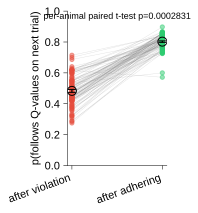

In [11]:
follow_next_result = qmodel.paired_by_violation(df_next, "Next_Chose_Higher_Q")
print(f"P(follow Q next trial | violation)={follow_next_result['after_violation_mean']:.3f} +/- "
      f"{follow_next_result['after_violation_sem']:.3f}, "
      f"P(follow Q next trial | adhered)={follow_next_result['after_adherence_mean']:.3f} +/- "
      f"{follow_next_result['after_adherence_sem']:.3f}")
print(f"Naive session-level paired t-test (n={follow_next_result['n_sessions']} sessions): "
      f"p={follow_next_result['naive_session_level_ttest_p']:.4e} -- manuscript text: p < 0.0001")
print(f"Per-animal-corrected paired t-test (n={follow_next_result['n_animals']} animals): "
      f"p={follow_next_result['per_animal_ttest_p']:.4f}")

plotting.plot_paired_violation_comparison(follow_next_result, "p(follows Q-values on next trial)", config,
                                            os.path.join(FIG_DIR, "follow_next_trial_by_violation.svg"))
show(os.path.join(FIG_DIR, "follow_next_trial_by_violation.svg"))
manifest["follow_next_trial_by_violation"] = {
    k: v for k, v in follow_next_result.items() if k != "session_pairs"
}

## Panel g
**Manuscript legend:** *"Session-level violation rate versus accuracy
(p(High Prob)) for each animal. Each dot represents one session, colored
light to dark by session date within animal (light = early, dark = late).
Dashed lines show linear regression fits. Violation rate was negatively
correlated with session accuracy for Fiona (r=-0.61, p=0.021), Sonic
(r=-0.62, p=0.017), and Sunflower (r=-0.77, p<0.001), but not for Knuckles
(r=-0.30, p=0.169) or Zazu (r=-0.09, p=0.770)."*

Not previously built. Per the standing constraint against tuning to match
printed values, the regression below is computed independently from this
pipeline's own reconstructed data/model fit -- the r/p values are reported
plainly whatever they come out to, not forced to match the quotes above.

Fiona: r=-0.608, p=0.0211 (n=14 sessions)
Knuckles: r=-0.297, p=0.1690 (n=23 sessions)
Sonic: r=-0.624, p=0.0170 (n=14 sessions)
Sunflower: r=-0.768, p=0.0000 (n=35 sessions)
Zazu: r=-0.086, p=0.7699 (n=14 sessions)
-- manuscript text: Fiona r=-0.61 p=0.021, Knuckles r=-0.30 p=0.169, Sonic r=-0.62 p=0.017, Sunflower r=-0.77 p<0.001, Zazu r=-0.09 p=0.770


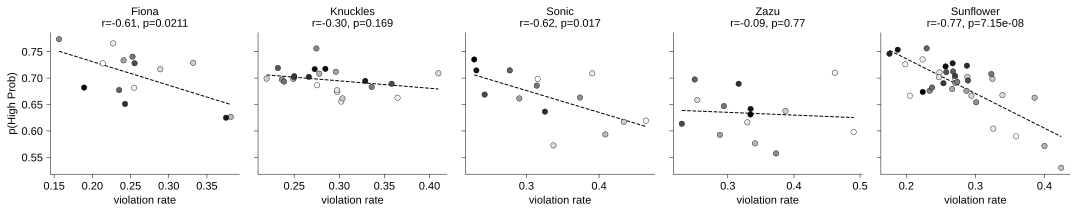

In [12]:
violation_vs_accuracy = qmodel.violation_rate_vs_accuracy_by_session(df_valid)
for animal, res in violation_vs_accuracy.items():
    print(f"{animal}: r={res['r']:.3f}, p={res['p']:.4f} (n={res['n_sessions']} sessions)")
print("-- manuscript text: Fiona r=-0.61 p=0.021, Knuckles r=-0.30 p=0.169, Sonic r=-0.62 p=0.017, "
      "Sunflower r=-0.77 p<0.001, Zazu r=-0.09 p=0.770")

plotting.plot_violation_vs_accuracy_by_animal(violation_vs_accuracy, config,
                                                os.path.join(FIG_DIR, "violation_rate_vs_accuracy.svg"))
show(os.path.join(FIG_DIR, "violation_rate_vs_accuracy.svg"))
manifest["violation_rate_vs_accuracy_by_animal"] = {
    animal: {k: v for k, v in res.items() if k != "sessions"}
    for animal, res in violation_vs_accuracy.items()
}

## Values manifest

In [13]:
manifest_path = os.path.join(MANIFEST_DIR, "SuppFig3.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")


Saved values manifest: ../outputs/values_manifests/SuppFig3.json
